In [1]:
# =========================================
# EDA - Superstore Sales Analysis
# Autor: Daniel AM
# Fecha: 2026-03-04
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Cargar datos
df = pd.read_csv('../../data/Sample - Superstore.csv', encoding='latin-1')

# Primeras filas
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
# Información general del dataset
print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nTipos de datos:")
print(df.dtypes)
print("\nNulos por columna:")
print(df.isnull().sum())

Shape: (9994, 21)

Columnas: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Tipos de datos:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Nulos por columna:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Se

In [3]:
# Estadísticas descriptivas de columnas numéricas
df[['Sales', 'Profit', 'Discount', 'Quantity']].describe().round(2)

,Sales,Profit,Discount,Quantity
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,28.66,0.16,3.79
std,623.25,234.26,0.21,2.23
min,0.44,-6599.98,0.00,1.00
25%,17.28,1.73,0.00,2.00
50%,54.49,8.67,0.20,3.00
75%,209.94,29.36,0.20,5.00
max,22638.48,8399.98,0.80,14.00


In [4]:
# Convertir fechas
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Ventas y profit por categoría
categoria = df.groupby('Category')[['Sales', 'Profit']].sum().round(2)
categoria['Margen_%'] = (categoria['Profit'] / categoria['Sales'] * 100).round(2)
categoria.sort_values('Sales', ascending=False)

,Sales,Profit,Margen_%
Category,,,
Technology,836154.03,145454.95,17.40
Furniture,741999.80,18451.27,2.49
Office Supplies,719047.03,122490.80,17.04


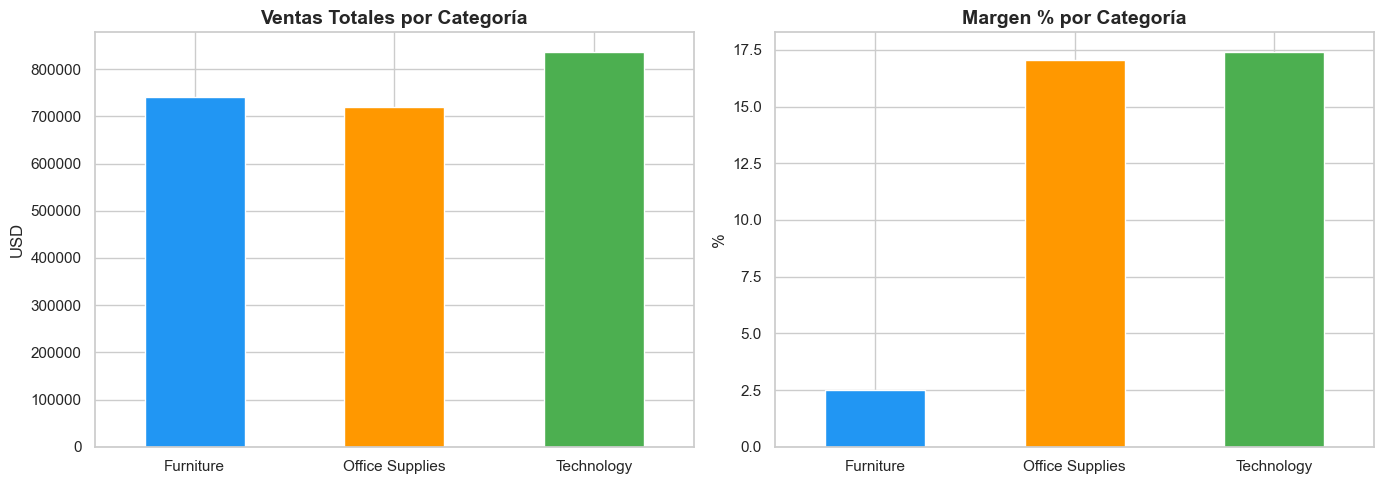

In [5]:
# Primera gráfica - Ventas y Profit por categoría
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Ventas
categoria['Sales'].plot(kind='bar', ax=ax[0], color=['#2196F3', '#FF9800', '#4CAF50'])
ax[0].set_title('Ventas Totales por Categoría', fontsize=14, fontweight='bold')
ax[0].set_xlabel('')
ax[0].set_ylabel('USD')
ax[0].tick_params(axis='x', rotation=0)

# Margen
categoria['Margen_%'].plot(kind='bar', ax=ax[1], color=['#2196F3', '#FF9800', '#4CAF50'])
ax[1].set_title('Margen % por Categoría', fontsize=14, fontweight='bold')
ax[1].set_xlabel('')
ax[1].set_ylabel('%')
ax[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../../outputs/01_ventas_margen_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Ventas por región
region = df.groupby('Region')[['Sales', 'Profit']].sum().round(2)
region['Margen_%'] = (region['Profit'] / region['Sales'] * 100).round(2)
region.sort_values('Sales', ascending=False)

,Sales,Profit,Margen_%
Region,,,
West,725457.82,108418.45,14.94
East,678781.24,91522.78,13.48
Central,501239.89,39706.36,7.92
South,391721.90,46749.43,11.93


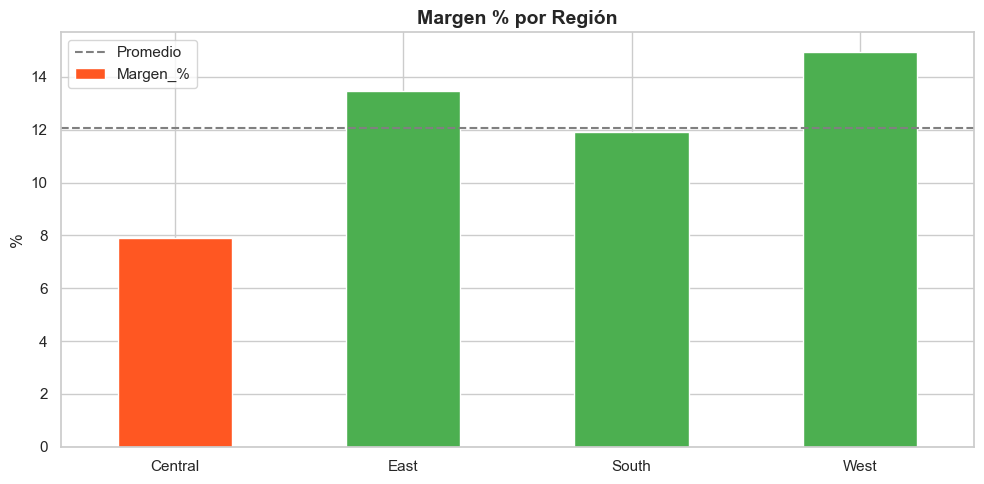

In [7]:
# Gráfica - Profit por región
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#4CAF50' if x > 10 else '#FF5722' for x in region['Margen_%']]
region['Margen_%'].plot(kind='bar', ax=ax, color=colors)

ax.set_title('Margen % por Región', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=0)
ax.axhline(y=region['Margen_%'].mean(), color='gray', linestyle='--', label='Promedio')
ax.legend()

plt.tight_layout()
plt.savefig('../../outputs/02_margen_region.png', dpi=150, bbox_inches='tight')
plt.show()

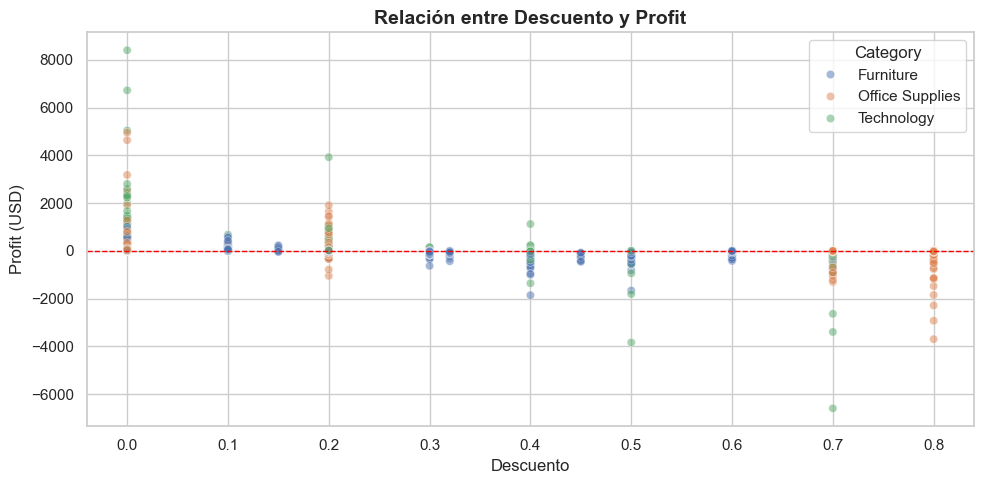

In [8]:
# ¿Los descuentos altos causan pérdidas?
fig, ax = plt.subplots(figsize=(10, 5))

sns.scatterplot(data=df, x='Discount', y='Profit', 
                hue='Category', alpha=0.5, ax=ax)

ax.set_title('Relación entre Descuento y Profit', fontsize=14, fontweight='bold')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Descuento')
ax.set_ylabel('Profit (USD)')

plt.tight_layout()
plt.savefig('../../outputs/03_descuento_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()

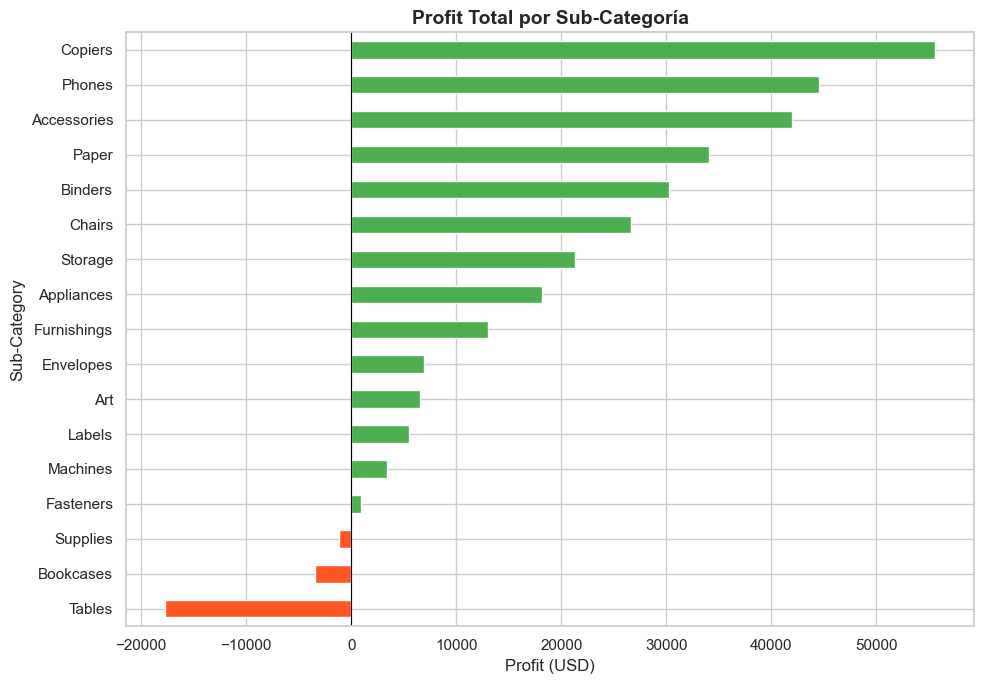

In [9]:
# Top 10 sub-categorías por profit
subcategoria = df.groupby('Sub-Category')['Profit'].sum().round(2)
subcategoria = subcategoria.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#FF5722' if x < 0 else '#4CAF50' for x in subcategoria]
subcategoria.plot(kind='barh', ax=ax, color=colors)

ax.set_title('Profit Total por Sub-Categoría', fontsize=14, fontweight='bold')
ax.set_xlabel('Profit (USD)')
ax.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../../outputs/04_profit_subcategoria.png', dpi=150, bbox_inches='tight')
plt.show()